# Systemy uczące się - Zad. dom. 2: Naiwny klassyfikator Bayesa

### Autor rozwiązania
Uzupełnij poniższe informacje umieszczając swoje imię i nazwisko oraz numer indeksu:


In [1]:
NAME = "Jakub Bilski"
ID = "155865"

Ten notebook zawiera dwa zadania związane z klasyfikatorem naiwnego Bayesa, oprócz implementacji zawiera on równie pytania na które trzeba odpowiedzieć.

## Zadanie 1
Zadanie polega na implementacji klasyfikatora naiwnego Bayesa dla zmiennych ciągłych gdzie za rozkłady cechy przyjmij rozkłady normalne.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

plt.style.use("ggplot")

Do testowania twojego rozwiązania użyj trzech generatorów danych sztucznych `generate1`, `generate2` oraz `generate3` (funkcje te przyjmują jako argument liczbę elementów do wygenerowania z każdej klasy - domyślnie $N=100$). Sposób ich wywołania jest przedstawiony poniżej:

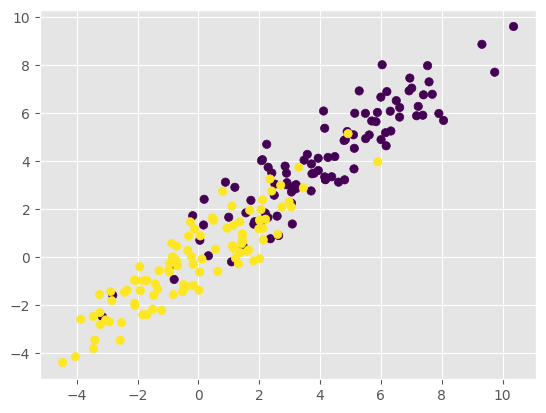

In [63]:
from helpers import generate1, generate2, generate3  # noqa

x, y = generate3()
plt.scatter(x[:, 0], x[:, 1], c=y)

W implementacji będzie przydatna klasa `norm` z pakietu `scipy`, która zwraca wartości funkcji gęstości prawdopodobieństwa rozkładu normalnego dla zmiennych ciągłych.

In [64]:
from scipy.stats import norm

# (x, mean, std)
norm.pdf(5, 0, 1)  # gęstość prawd. dla 5 z rozkładu standardowego
norm.logpdf(5, 0, 1)  # logarytm gęstości prawd. dla 5 z rozkładu standardowego

np.float64(-13.418938533204672)

Zaimplementuj klasyfikator naiwnego Bayesa dla zmiennych ciągłych. Pamiętaj o zabezpieczniu się przed problemem wynikającym z mnożenia wielu małych liczb (prawdopodobieństw).

In [65]:
class GaussianNaiveBayes():
    def __init__(self) -> None:
        self.means = {}
        # Słownik, który docelowo powinien zawierać tablicę/wektor warunkowych średnich dla każdego atrybutu
        # Każda tablica/wektor powinna być typu np.array
        # np. 1) means[1] powinno zawierać wektor średnich wartości atrybutów  dla klasy o indeksie 1
        #     2) means[0][1] powinno zawierać średnią 1 atrybutu dla klasy o indeksie 0
        # (Możesz spróbować zaimplementować efektywniejszą implementację używając macierzy)
        self.stds = {}
        # Analogiczna struktura dla odchyleń standardowych
        self.class_log_prob = None
        # Wektor zawierający logarytmy prawdopodobieństwa dla każdej z klas
        # np. class_log_prob[1] zawiera logarytm prawdopodobieństwa, że klasa jest równa 1 P(C=1)
        self.classes = None

    def fit(self, x: np.ndarray, y: np.ndarray) -> None:
        """Funkcja trenująca klasyfikator naiwnego Bayesa na podstawie danych x i y.

        Args:
            x (np.ndarray): macierz danych wejściowych, gdzie każdy wiersz to obserwacja
            y (np.ndarray): wektor indeksów klas (0 lub 1) dla każdej obserwacji

        Returns:
            None
        """
        self.classes = np.unique(y)
        n_samples = x.shape[0]
        self.class_log_prob = np.zeros(len(self.classes)) # używamy logarytmów, aby łatwiej sumować prawdopodobieństwa

        for c in self.classes:
          x_c = x[y==c] #wybeieramy obserwacje z danej klasy
          self.class_log_prob[c] = np.log(x_c.shape[0] / n_samples) # log P(C_c) - logarytm naturalny częstości klasy w zbiorze treningowym
          self.means[c] = np.mean(x_c, axis=0)
          self.stds[c] = np.std(x_c, axis=0)
          self.stds[c] = np.maximum(self.stds[c], 1e-9) #zabezpieczenie, gdyby w kolumnie były te same wartości, bo logarytm z zera to -inf

    def predict_proba(self, x: np.ndarray) -> np.ndarray:
        """Funkcja zwracająca prawdopodobieństwa przynależności do klas dla każdej obserwacji w macierzy x.

        Args:
            x (np.ndarray): macierz danych wejściowych, gdzie każdy wiersz to obserwacja

        Returns:
            np.ndarray: macierz o dwóch kolumnach (dwie klasy) w której kolejne wiersze  zawierają prawdopodobieństwa P(c|x)
                przynależności dla klas dla kolejnych obserwacji w macierzy x

        """
        n_samples = x.shape[0]
        n_classes = len(self.means)

        log_posteriors = np.zeros((n_samples, n_classes)) # macierz logarytmów prawdopodobieństw klas dla każdej próbki

        for idx, c in enumerate(self.classes):
          mean = self.means[c]
          std = self.stds[c]
          var = std**2 + 1e-9 #unikamy dzielenia przez zero

          log_likelihood = -0.5 * np.log(2*np.pi*var)-((x-mean)**2)/(2*var) #logarytm gęstości rozkładu normalnego dla każdej cechy
          log_likelihood_sum = np.sum(log_likelihood, axis=1) #zamieniamy mnożenie prawdopodobieństw na sumę logarytmów
          log_posteriors[:, idx] = self.class_log_prob[c] + log_likelihood_sum #połączenie prawd. a priori klasy z wiarygodnością

        row_max = np.max(log_posteriors, axis=1, keepdims=True)
        exp_shifted = np.exp(log_posteriors - row_max)
        prob = exp_shifted / np.sum(exp_shifted, axis=1, keepdims=True) #normalizacja - suma prawdopodobieństw równa 1

        return prob

    def predict(self, x: np.ndarray) -> np.ndarray:
        # Gotowa funkcja wybierająca klasę z największym prawdopodobieństwem
        prob = self.predict_proba(x)
        return np.argmax(prob, axis=1)


Przetestuj twój klasyfikator na wygenerowanych wcześniej danych.

In [68]:
from helpers import GaussianBayes

gnb = GaussianNaiveBayes()
gnb.fit(x, y)

# Trafność na zbiorze uczącym
np.mean(gnb.predict(x) == y)

np.float64(0.845)

Narysowanie nauczonego klasyfikatora

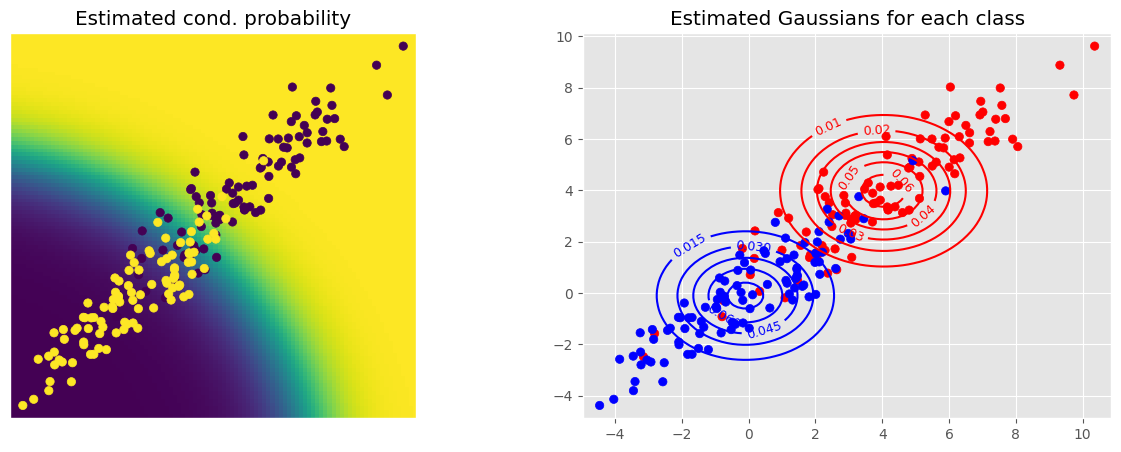

In [69]:
from helpers import plot_gaussian_bayes

plot_gaussian_bayes(x, y, gnb)

Użyj funkcji do generowania danych, aby wygenerować zbiór testowy oraz sprawdź na nim trafność klasyfikacji metody.

In [61]:
x_test, y_test = generate1(1000)
np.mean(gnb.predict(x_test) == y_test)

np.float64(0.992)

**Ćwiczenia**
 - Pamiętaj o przetestowaniu Twojego algorytmu dla wszystkich trzech generatorów danych. W których ze zbiorów założenie o warunkowej niezależności zmiennych jest spełnione? Jak brak spełnienia tego założenia wpływa na działanie klasyfikatora?
 - Z pliku `helpers` zaimportuj klasę `GaussianBayes` (identyczna obsługa jak tej zaimplementowanej przez Ciebie). Klasa implementuje algorytm Bayesa bez założenia o niezależności zmiennych (ale z założeniem o normalności rozkładów). Porównaj wyniki - szczególnie dla zbiorów dla których założenie o warunkowej niezależności zmiennych nie jest spełnione.
 - Klasyfikatora `GaussianBayes` nie można wytrenować na zbiorach które mają mniej niż 3 przykłady dla każdej z klas. Jak myślisz dlaczego? Jak ten problem będzie się zmieniał dla zbiorów o wysokiej liczbie cech?
 - Nawet używając klasyfikatora `GaussianBayes`, który zakłada kompletny model zależności i prawidłowy rozkład danych (nasze dane są generowane z rozkładów normalnych) - często nie jest w stanie uzyskać 100% trafności nawet na zbiorze uczącym. Jak myślisz, dlaczego?
 - Czy gdyby przepisać do klasyfikatora prawdziwe wartości średnich i macierz wariancji-kowariancji cech (z generatora) - uzyskalibyśmy 100% trafność? Co możemy powiedzieć o takim klasyfikatorze? Czy jest możliwe uzyskanie klasyfikatora bardziej trafnego niż taki?

 Odpowiedzi na dwa ostatnie pytania zostaną sprawdzone: wpisz swoje odpowiedzi poniżej.

1. Dane z 1. generatora tworzą najbardziej kuliste klastry, bez wyraźnego nachylenia w żadnym kierunku, co oznacza, że założenie o warunkowej niezależnosći jest najbliższe spełnienia. Im silniejsza korelacja między cechami, tym gorzej działa Naive Bayes, bo model sam w sobie nie widzi tej zależności, granice decyzyjne powstają w złych miejscach.

2. GaussianBayes nie zakłada niezależności, modeluje pełny rozkład Gaussa, czyli oblicza wariancje i kowariancje między cechami. Powinien dawać lepsze dopasowania dla zbiorów, gdzie założenie o warunkowej niezależności nie jest spełnione.

3. W przypadku modelowania 2D, jeden punkt (x1, x2) daje nam tylko informację o położeniu na płaszczyźnie. Dwa punkty zawsze leżą na jednej prostej - nie zmieniają się w dwóch niezależnych kierunkach. Aby obliczyć gęstość rozkładu, konieczne jest wyznaczenie odwrotności tej macierzy. Przy bardzo małej liczbie przykładów w klasie macierz kowariancji staje się osobliwa (wyznacznik=0) i nie można jej odwrócić.

4. Rozkłady normalne różnych klas mogą się częściowo nakładać, czyli może dochodzić do sytuacji, w której punkt z jednej klasy może mieć większe prawdopodobieństwo pod rozkładem innej klasy niż pod własnym rozkładem. Nie da się wtedy jednoznacznie rozróżnić klas, bo według modelu obie klasy są w danym miejscu możliwe. Przypisanie punktu do klasy odbywa się na podstawie obliczanego prawdopodobieństwa, więc jeśli punkt znajduje się w obszarze, gdzie rozkłady klas się nakładają, to klasyfikator może popełnić błąd.

5. Klasyfikator wykorzystujący prawdziwe parametry rozkładów minimalizuje średnie prawdopodobieństwo błędu klasyfikacji, ale nie rozwiązuje problemu nakładania się rozkładów. Nawet idealnie dopasowany model może przez to popełnić błąd. Wynika to jednak z samej natury danych, a nie wad klasyfikatora. Nie istnieje zatem klasyfikator, który byłby bardziej trafny w sensie średniego błędu dla tego samego rozkładu danych.

# Zadanie 2
Klasyfikator naiwnego Bayesa często jest używany do klasyfikacji tekstów. Przetestuj działanie algorytmów na podanym rzeczywistym zbiorze danych:
> The 20 newsgroups dataset comprises around 18000 newsgroups posts on 20 topics split in two subsets: one for training (or development) and the other one for testing (or for performance evaluation). The split between the train and test set is based upon a messages posted before and after a specific date.

Podany zbiór jest wieloklasowy, więc poniższy kod wybiera z niego podzbiór postów tylko z dwóch tematów.

In [9]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

categories = ['comp.graphics', 'sci.space']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories)

vectorizer = TfidfVectorizer(binary=True, use_idf=False, norm=None)  # Przekształcenie tekstu na cechy binarne
vectors = vectorizer.fit_transform(newsgroups_train.data)
vectors_test = vectorizer.transform(newsgroups_test.data)
vectors = vectors.toarray()
vectors_test = vectors_test.toarray()

Dokumenty w zbiorze można wyświetlić w następujący sposób.

In [10]:
newsgroups_train.data[0:3]

['From: ab@nova.cc.purdue.edu (Allen B)\nSubject: Re: thining algorithm\nOrganization: Purdue University\nLines: 15\n\nIn article <1q7615INNmi@shelley.u.washington.edu> kshin@stein.u.washington.edu  \n(Kevin Shin) writes:\n> I am trying obtain program to preprocess handwriting characters.\n> Like thining algorithm, graph alogrithm.\n> Do anyone know where I can obtain those?\n\nI usually use "Algorithms for graphics and image processing" by\nTheodosios Pavlidis, but other people here got them same idea and now\n3 of 4 copies in the libraries have been stolen!\n\nAnother reference is "Digital Image Processing" by Gonzalez and\nWintz/Wood, which is widely available but a little expensive ($55\nhere- I just checked today).\n\nab\n',
 "From: stephens@geod.emr.ca (Dave Stephenson)\nSubject: Re: Clementine Science Team Selected\nNntp-Posting-Host: ngis.geod.emr.ca\nOrganization: Dept. of Energy, Mines, and Resources, Ottawa\nLines: 32\n\nnickh@CS.CMU.EDU (Nick Haines) writes:\n\n>In article 

Analogicznie możemy uzyskać dostęp do informacji o klasach.

In [11]:
newsgroups_train.target[0:3]

array([0, 1, 0])

i do "zbinaryzowanego" tekstu

In [12]:
vectors[0:3]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

Wytrenuj klasyfikator Naiwnego Bayesa z rozmywaniem estymat (patrz pakiet `sklearn`) i sprawdż jego trafność na zbiorze uczącym i testowym.

In [72]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score

model = BernoulliNB()
model.fit(vectors, newsgroups_train.target)

train_acc = accuracy_score(newsgroups_train.target, model.predict(vectors))
test_acc = accuracy_score(newsgroups_test.target, model.predict(vectors_test))

print(f"Train accuracy: {train_acc}")
print(f"Test accuracy: {test_acc}")


Train accuracy: 0.9405267629566695
Test accuracy: 0.8671775223499362


In [73]:
import numpy as np

feature_names = np.array(vectorizer.get_feature_names_out())
log_probs = model.feature_log_prob_
log_ratio = log_probs[1] - log_probs[0]
top_space = np.argsort(log_ratio)[-15:][::-1]
top_graphics = np.argsort(log_ratio)[:15]

print("Najsilniejsze wskaźniki: sci.space")
for i in top_space:
    print(f"  {feature_names[i]:20s}  log-ratio: {log_ratio[i]:.3f}")

print("Najsilniejsze wskaźniki: comp.graphics")
for i in top_graphics:
    print(f"  {feature_names[i]:20s}  log-ratio: {log_ratio[i]:.3f}")

neutral = np.argsort(np.abs(log_ratio))[:15]
print("Słowa słabo wskazują na którąkolwiek z klas")
for i in neutral:
    print(f"  {feature_names[i]:20s}  log-ratio: {log_ratio[i]:.3f}")


Najsilniejsze wskaźniki: sci.space
  prb                   log-ratio: 4.329
  henry                 log-ratio: 4.275
  lunar                 log-ratio: 4.247
  spacecraft            log-ratio: 4.204
  orbit                 log-ratio: 4.189
  moon                  log-ratio: 4.045
  billion               log-ratio: 4.028
  nsmca                 log-ratio: 3.974
  orbital               log-ratio: 3.955
  vehicle               log-ratio: 3.917
  funding               log-ratio: 3.856
  sky                   log-ratio: 3.835
  rocket                log-ratio: 3.813
  landing               log-ratio: 3.648
  utzoo                 log-ratio: 3.648
Najsilniejsze wskaźniki: comp.graphics
  vga                   log-ratio: -3.927
  tiff                  log-ratio: -3.704
  polygon               log-ratio: -3.512
  pov                   log-ratio: -3.383
  umich                 log-ratio: -3.273
  viewer                log-ratio: -3.273
  vesa                  log-ratio: -3.234
  svga           

In [74]:
from itertools import combinations

all_categories = [
    'alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc',
    'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x',
    'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball',
    'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med',
    'sci.space', 'soc.religion.christian', 'talk.politics.guns',
    'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc'
]

results = []
for c1, c2 in combinations(all_categories, 2):
    train = fetch_20newsgroups(subset='train', categories=[c1, c2])
    test = fetch_20newsgroups(subset='test', categories=[c1, c2])
    vec = TfidfVectorizer(binary=True, use_idf=False, norm=None)
    X_tr = vec.fit_transform(train.data).toarray()
    X_te = vec.transform(test.data).toarray()
    m = BernoulliNB(alpha=1.0).fit(X_tr, train.target)
    acc = accuracy_score(test.target, m.predict(X_te))
    results.append((acc, c1, c2))

results.sort()
print("\n10 najtrudniejszych par:")
for acc, c1, c2 in results[:10]:
    print(f"  {acc:.4f}  {c1}  vs  {c2}")

print("\n10 najłatwiejszych par:")
for acc, c1, c2 in results[-10:][::-1]:
    print(f"  {acc:.4f}  {c1}  vs  {c2}")


10 najtrudniejszych par:
  0.5013  comp.os.ms-windows.misc  vs  comp.sys.ibm.pc.hardware
  0.5045  comp.os.ms-windows.misc  vs  comp.sys.mac.hardware
  0.5070  comp.graphics  vs  comp.os.ms-windows.misc
  0.5133  comp.os.ms-windows.misc  vs  comp.windows.x
  0.5222  comp.os.ms-windows.misc  vs  sci.electronics
  0.5709  comp.os.ms-windows.misc  vs  rec.autos
  0.5816  comp.os.ms-windows.misc  vs  misc.forsale
  0.5833  comp.os.ms-windows.misc  vs  rec.motorcycles
  0.6536  comp.os.ms-windows.misc  vs  rec.sport.baseball
  0.6797  comp.os.ms-windows.misc  vs  sci.med

10 najłatwiejszych par:
  0.9937  rec.motorcycles  vs  rec.sport.baseball
  0.9937  sci.crypt  vs  soc.religion.christian
  0.9912  rec.sport.hockey  vs  sci.space
  0.9899  comp.windows.x  vs  rec.sport.hockey
  0.9899  comp.windows.x  vs  rec.sport.baseball
  0.9899  comp.sys.ibm.pc.hardware  vs  rec.motorcycles
  0.9887  rec.autos  vs  rec.sport.baseball
  0.9874  comp.windows.x  vs  rec.motorcycles
  0.9874  comp.wind

**Ćwiczenia**
 - Dlaczego klasyfikator Naiwnego Bayesa dość dobrze sprawdza się do powyższego zadania i analogicznych?
 - Przeanalizuj wartości estymat prawdopodobieństw. Które cechy/słowa są najlepszymi wskaźnikami dla podanych klas? Jakie słowa bardzo słabo wskazują na którąkolwiek z klas?
 - Czy byłoby możliwe wytrenowanie równie skutecznego klasyfikatora z mniejszą liczbą cech? W jaki sposób można by to uzyskać?
 - Analizowany zbiór jest oryginalnie wieloklasowy z tego powodu możemy go wykorzystać do wielu testów wybierając różne pary klas. Pełna lista tematów: 'alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc'
 - Czy są pary tematów dla których ten klasyfikator działa znacząco gorzej?
 - Jakie są zalety stosowania klasyfikatora Bayesa dla tego problemu (i w ogólności)? Czy do tego problemu sprawdziłyby się reguły lub drzewa decyzyjne? Dlaczego?

 Odpowiedzi na kropki 1, 3 i 6 wpisz poniżej - zostaną sprawdzone.

1. W rzeczywistości słowa są ze sobą skorelowane, ale Naiwny Bayes zakłada, że są one od siebie niezależne. To błędne założenie paradoksalnie upraszcza obliczenia i często prowadzi do bardzo dobrych wyników. Klasyfikator nie wie, że słowa są skorelowane - "naiwnie" wierzy, że każe słowo pojawia się w tekście całkowicie niezależnie od innych. Dzięki temu zamiast liczyć skomplikowane prawdopodobieństwa wspólne, po prostu mnoży przez siebie prawdopodobieństwa pojedynczych słów.

2. output powyżej

3. Np. poprzez selekcję cech testem chi-kwadrat - zostawiamy tylko te cechy, które najlepiej rozróżniają klasy, a resztę odrzucamy. Można również usunąć słowa zbyt rzadkie lub zbyt częste.

5. output powyżej

6. - bardzo szybki trening
- dobrze działa przy małej ilości danych treningowych
- łatwa obsługa wieloklasowości
- interpretowalność
- odporność na nieistotne cechy

Drzewo przy każdym splicie wybiera jedno słowo i dzieli dokumenty na zawiera/nie zawiera. To oznacza, że decyzja opiera się na pojedynczych słowach, a nie na agregacji słów z całego dokumentu. Naiwny Bayes sumuje logarytmy prawdopodobieństw ze wszystkich słów jednocześnie, co jest podejściem bardziej naturalnym, ponieważ informacja o temacie jest rozproszona po wielu słowach. W przypadku reguł byłoby podobnie - duża liczba cech generuje dużą liczbę reguł trudną do skonstruowania, przetworzenia i ewentualnego dostosowywania na bieżąco. Ponadto podatność na overfitting.



